In [1]:
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import geopandas as gpd
import contextily as ctx
import mycolorpy.colorlist as mcp
import utils

from collections import Counter
from matplotlib.patches import Rectangle, ConnectionPatch
from shapely.geometry import Point


In [2]:
def add_safe_basemap(ax, source=None, attribution=False):
    """Add a light basemap when tiles are reachable; keep plotting if the tile server fails."""
    if source is None:
        source = ctx.providers.CartoDB.PositronNoLabels
    try:
        ctx.add_basemap(ax, source=source, attribution=attribution)
        return True
    except Exception as exc:
        print(f"Basemap skipped: {type(exc).__name__}: {exc}")
        return False


In [3]:
def load_aimsun(plan_name, rep=None):
    df = pd.read_parquet(f"../data/processed/{plan_name}_aimsun.parquet")
    if rep == None:
        return df
    else:
        return df[df["rep"] == rep].copy()


def load_network(plan_name, rep=None):
    df = pd.read_parquet(f"../data/processed/{plan_name}_network.parquet")
    if rep == None:
        return df
    else:
        return df[df["rep"] == rep].copy()


def load_critical(plan_name, rep=-1):
    df_summary = pd.read_parquet(f"../data/processed/{plan_name}_critical_summary.parquet")
    df_vector = pd.read_parquet(f"../data/processed/{plan_name}_critical_vector.parquet")

    critical_time = df_summary.loc[df_summary["rep"] == rep, "critical_time"].iloc[0]

    critical_loc = df_vector.loc[
        (df_vector["rep"] == rep) & (df_vector["type"] == "critical_loc"),
        "value"
    ].to_numpy()

    intersection = df_vector.loc[
        (df_vector["rep"] == rep) & (df_vector["type"] == "intersection"),
        "value"
    ].to_numpy()

    return critical_time, critical_loc, intersection


In [4]:
def analysis(plan_name):
    """
    Reconstruct the old outputs from saved parquet files.
    Only uses rep != -1.
    """
    df_network = pd.read_parquet(f"../data/processed/{plan_name}_network.parquet")
    df_aimsun = pd.read_parquet(f"../data/processed/{plan_name}_aimsun.parquet")

    reps = sorted([r for r in df_network["rep"].unique() if r != -1])

    if len(reps) == 0:
        raise ValueError(
            f"No repetition data found in {plan_name}_network.parquet. "
            f"Available reps: {sorted(df_network['rep'].unique())}"
        )

    l_gs, n_cs, s_gs = [], [], []
    mfds, densitys, speeds, ttimes = [], [], [], []
    co2s, noxs, vocs, pms = [], [], [], []

    for rep in reps:
        # ---------- network ----------
        net_rep = df_network[df_network["rep"] == rep].copy()

        l_g = net_rep.loc[net_rep["metric"] == "l_g"].sort_values("time")["value"].to_numpy()
        n_c = net_rep.loc[net_rep["metric"] == "n_c"].sort_values("time")["value"].to_numpy()
        s_g = net_rep.loc[net_rep["metric"] == "s_g"].sort_values("time")["value"].to_numpy()

        if len(l_g) == 0 or len(n_c) == 0 or len(s_g) == 0:
            continue

        l_gs.append(l_g)
        n_cs.append(n_c)
        s_gs.append(s_g)

        # ---------- aimsun ----------
        aim_rep = df_aimsun[df_aimsun["rep"] == rep].copy()

        agg = (
            aim_rep.groupby("ent")
            .agg({
                "flow": "mean",
                "density": "mean",
                "speed": "mean",
                "ttime": "mean",
                "CO2_interurban": "mean",
                "NOx_interurban": "mean",
                "VOC_interurban": "mean",
                "PM_interurban": "mean",
            })
            .reset_index()
            .sort_values("ent")
        )

        # If your old MFD uses another definition, change this line.
        mfds.append(agg["flow"].to_numpy())
        densitys.append(agg["density"].to_numpy())
        speeds.append(agg["speed"].to_numpy())
        ttimes.append(agg["ttime"].to_numpy())
        co2s.append(agg["CO2_interurban"].to_numpy())
        noxs.append(agg["NOx_interurban"].to_numpy())
        vocs.append(agg["VOC_interurban"].to_numpy())
        pms.append(agg["PM_interurban"].to_numpy())

    if len(l_gs) == 0:
        raise ValueError(
            f"Repetition IDs exist, but no usable l_g / n_c / s_g data were found for plan {plan_name}."
        )

    return l_gs, n_cs, s_gs, mfds, densitys, speeds, ttimes, co2s, noxs, vocs, pms


In [5]:
def _line_endpoints(geom):
    """
    Return start/end coordinates of a LineString or MultiLineString.
    """
    if geom.geom_type == "LineString":
        coords = list(geom.coords)
        return np.array(coords[0]), np.array(coords[-1])
    elif geom.geom_type == "MultiLineString":
        first = list(geom.geoms[0].coords)
        last = list(geom.geoms[-1].coords)
        return np.array(first[0]), np.array(last[-1])
    else:
        return None, None


def _endpoint_match_score(a1, a2, b1, b2):
    """
    Distance between two undirected segments:
    compare both orientations and take the smaller one.
    """
    s1 = np.linalg.norm(a1 - b1) + np.linalg.norm(a2 - b2)
    s2 = np.linalg.norm(a1 - b2) + np.linalg.norm(a2 - b1)
    return min(s1, s2)


def _match_edges_to_shapefile(G_primal, selected_edges, roads_gdf):
    """
    Match selected G_primal edges to shapefile geometries using endpoints.
    Returns a GeoDataFrame with true curved geometry from shapefile.
    """
    # precompute shapefile endpoints
    shp = roads_gdf.copy()
    shp["_p1"], shp["_p2"] = zip(*shp.geometry.apply(_line_endpoints))

    rows = []

    for u, v, k, e in selected_edges:
        x1, y1 = G_primal.nodes[u]["loc"].x, G_primal.nodes[u]["loc"].y
        x2, y2 = G_primal.nodes[v]["loc"].x, G_primal.nodes[v]["loc"].y
        p1 = np.array([x1, y1])
        p2 = np.array([x2, y2])

        # score every shapefile feature by endpoint similarity
        valid = shp[shp["_p1"].notna()].copy()
        valid["_score"] = valid.apply(
            lambda r: _endpoint_match_score(p1, p2, r["_p1"], r["_p2"]),
            axis=1
        )

        # take best match
        best = valid.sort_values("_score").iloc[0]

        rows.append({
            "u": u,
            "v": v,
            "k": k,
            "name": e.get("name"),
            "cluster": e.get("cluster"),
            "geometry": best.geometry
        })

    gdf = gpd.GeoDataFrame(rows, geometry="geometry", crs=roads_gdf.crs)
    return gdf


def plot_basemap_with_clusters(total, ent, figsize=(3, 5.2), save_path=None, top_k_clusters=8):
    # ===== shapefile base =====
    roads = gpd.read_file("../data/external/aimsun_topo/section_edit.shp")
    if roads.crs is None:
        raise ValueError("Shapefile has no CRS.")
    roads_3857 = roads.to_crs(epsg=3857)

    # ===== graph =====
    load = utils.LoadData()
    G_primal, G_dual = load.load_map_data(
        '../data/external/aimsun_topo/section_edit.shp',
        '../data/external/aimsun_topo/nodes.shp'
    )

    # ===== update dual graph at ent =====
    total_ent = total[total["ent"] == ent]
    G_dual_copy = G_dual.copy()

    for _, row in total_ent.iterrows():
        oid = int(row["oid"])
        if oid in G_dual_copy.nodes:
            G_dual_copy.nodes[oid]["congest"] = row["if_congest"]

    # ===== congested subgraph =====
    sub_nodes_congest = [
        u for u, d in G_dual_copy.nodes(data=True)
        if d.get("congest", 0) == 1
    ]
    G_congest_dual = G_dual_copy.subgraph(sub_nodes_congest)

    components = sorted(
        nx.connected_components(G_congest_dual),
        key=len,
        reverse=True
    )[:top_k_clusters]

    top_nodes = set().union(*components) if components else set()

    # ===== original selection logic from your old code =====
    selected_edges = [
        (u, v, k, e)
        for u, v, k, e in G_primal.edges(data=True, keys=True)
        if e.get("name") in top_nodes
    ]

    # ===== assign cluster ids on selected edges =====
    node_to_cluster = {}
    for idx, comp in enumerate(components, start=1):
        for name in comp:
            node_to_cluster[name] = idx

    selected_edges_with_cluster = []
    for u, v, k, e in selected_edges:
        e2 = dict(e)
        e2["cluster"] = node_to_cluster.get(e.get("name"))
        selected_edges_with_cluster.append((u, v, k, e2))

    if len(selected_edges_with_cluster) == 0:
        print("No selected edges found.")
        return roads_3857, None
    
    # ===== build node GeoDataFrame =====
    node_ids = set()
    for u, v, k, e in selected_edges_with_cluster:
        node_ids.add(u)
        node_ids.add(v)

    node_rows = []
    for n in node_ids:
        x = G_primal.nodes[n]["loc"].x
        y = G_primal.nodes[n]["loc"].y
        node_rows.append({
            "node": n,
            "geometry": Point(x, y)
        })

    gdf_nodes = gpd.GeoDataFrame(node_rows, geometry="geometry", crs=roads.crs)
    gdf_nodes_3857 = gdf_nodes.to_crs(epsg=3857)

    # ===== critical step: use shapefile geometry, not straight lines =====
    gdf_clusters = _match_edges_to_shapefile(G_primal, selected_edges_with_cluster, roads)
    gdf_clusters_3857 = gdf_clusters.to_crs(epsg=3857)

    # ===== color mapping =====
    clusters_sorted = sorted(gdf_clusters["cluster"].dropna().unique())
    color_candidate = mcp.gen_color(cmap="Set2", n=len(clusters_sorted)) if len(clusters_sorted) > 0 else []
    cluster_to_color = {c: color_candidate[i] for i, c in enumerate(clusters_sorted)}

    # ===== extent =====
    xmin, ymin, xmax, ymax = roads_3857.total_bounds
    dx = xmax - xmin
    dy = ymax - ymin
    xmin -= 0.02 * dx
    xmax += 0.02 * dx
    ymin -= 0.02 * dy
    ymax += 0.02 * dy

    # ===== plot =====
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    add_safe_basemap(ax)

    roads_3857.plot(
        ax=ax,
        color="#A8A8A8",
        linewidth=1,
        alpha=0.5,
        zorder=2
    )

    for c in clusters_sorted:
        gdf_c = gdf_clusters_3857[gdf_clusters_3857["cluster"] == c]
        gdf_c.plot(
            ax=ax,
            color=cluster_to_color[c],
            linewidth=1.4,
            alpha=0.95,
            zorder=4
        )
    
    ax.text(
        0.05, 0.10,
        f"{6 + ent // 60}:{ent % 60:02d} a.m.",
        fontsize=15,
        color="black",
        transform=ax.transAxes,
        ha="left",
        va="bottom"
    )

    # ===== add black frame =====
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    rect = Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        fill=False,
        edgecolor="black",
        linewidth=1.2,
        zorder=10,
        clip_on=False
    )

    ax.add_patch(rect)

    ax.set_aspect("auto")
    ax.set_axis_off()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")

    plt.show()

    return roads_3857, gdf_clusters_3857


1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


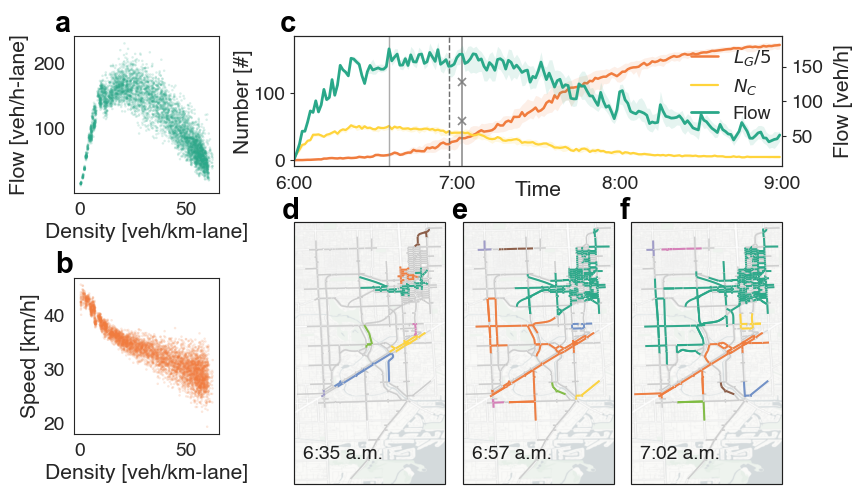

In [6]:
# Fig. 1 composite panel
FIG1_PALETTE = {
    "teal": "#2AA889",
    "teal_dark": "#0B6F62",
    "orange": "#F07C3E",
    "orange_dark": "#B64A26",
    "yellow": "#FFD43B",
    "gray": "#A8A8A8",
    "black": "#1F1F1F",
}

_FIG1_MAP_CACHE = None


def set_fig1_panel_style():
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "mathtext.fontset": "dejavusans",
        "font.size": 13.8,
        "axes.labelsize": 15.2,
        "axes.titlesize": 15.2,
        "xtick.labelsize": 13.8,
        "ytick.labelsize": 13.8,
        "legend.fontsize": 13.2,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    })


def add_fig1_label(ax, label, x=-0.12, y=1.04):
    ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        fontsize=21.0,
        fontfamily="Arial",
        fontweight="heavy",
        ha="left",
        va="bottom",
        clip_on=False,
        color="black",
    )


def get_fig1_analysis_arrays(plan_name="Fix"):
    l_gs, n_cs, s_gs, mfds, densitys, speeds, ttimes, co2s, noxs, vocs, pms = analysis(plan_name)
    return {
        "l_g": np.array(l_gs),
        "n_c": np.array(n_cs),
        "flow": np.array(mfds),
        "density": np.array(densitys),
        "speed": np.array(speeds),
    }


def plot_cluster_flow_panel(ax, arrays):
    x = np.arange(arrays["l_g"].shape[1]) / 60 + 6
    interval = 60

    lg_raw = np.percentile(arrays["l_g"], 50, axis=0)
    flow_med = np.percentile(arrays["flow"], 50, axis=0)
    max_time = np.argmax(flow_med)
    cg_percolation_time = np.argmax(lg_raw[interval:] - lg_raw[:-interval])

    lg_med = lg_raw / 5
    lg_q25 = np.percentile(arrays["l_g"], 25, axis=0) / 5
    lg_q75 = np.percentile(arrays["l_g"], 75, axis=0) / 5
    nc_med = np.percentile(arrays["n_c"], 50, axis=0)
    nc_q25 = np.percentile(arrays["n_c"], 25, axis=0)
    nc_q75 = np.percentile(arrays["n_c"], 75, axis=0)
    flow_q25 = np.percentile(arrays["flow"], 25, axis=0)
    flow_q75 = np.percentile(arrays["flow"], 75, axis=0)

    ax.fill_between(x, lg_q25, lg_q75, color=FIG1_PALETTE["orange"], alpha=0.12, linewidth=0)
    ax.plot(x, lg_med, color=FIG1_PALETTE["orange"], linewidth=1.8, label=r"$L_G/5$")
    ax.fill_between(x, nc_q25, nc_q75, color=FIG1_PALETTE["yellow"], alpha=0.16, linewidth=0)
    ax.plot(x, nc_med, color=FIG1_PALETTE["yellow"], linewidth=1.6, label=r"$N_C$")

    event_times = {
        "max_flow": 6 + 35 / 60,
        "percolation": 6 + 57 / 60,
        "late": 6 + 62 / 60,
    }
    ax.axvline(event_times["max_flow"], color="#8A8A8A", linewidth=1.05, alpha=0.70)
    ax.axvline(event_times["percolation"], color="#666666", linewidth=1.05, linestyle="--", alpha=0.95)
    ax.axvline(event_times["late"], color="#777777", linewidth=1.15, alpha=0.85, zorder=8)
    ax.plot(
        [event_times["late"]] * 2,
        [0.35, 0.65],
        transform=ax.get_xaxis_transform(),
        color="#777777",
        linestyle="none",
        marker="x",
        markersize=5.8,
        markeredgewidth=1.20,
        alpha=0.85,
        clip_on=True,
        zorder=9,
    )

    ax.set_xlim(x.min(), x.max())
    ax.set_xticks([6, 7, 8, 9])
    ax.set_xticklabels(["6:00", "7:00", "8:00", "9:00"])
    ax.set_xlabel("Time", labelpad=-8)
    ax.set_ylabel("Number [#]", labelpad=4)
    ax.yaxis.set_label_coords(-0.085, 0.5)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
    ax.grid(False)
    ax.set_axisbelow(True)

    ax2 = ax.twinx()
    ax2.fill_between(x, flow_q25, flow_q75, color=FIG1_PALETTE["teal"], alpha=0.12, linewidth=0)
    ax2.plot(x, flow_med, color=FIG1_PALETTE["teal"], linewidth=2.0, label="Flow")
    ax2.set_ylabel("Flow [veh/h]", labelpad=4)
    ax2.yaxis.set_label_coords(1.105, 0.5)
    for spine in ax2.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(
        lines1 + lines2,
        labels1 + labels2,
        frameon=False,
        loc="upper right",
        ncol=1,
        handlelength=1.5,
        borderaxespad=0.2,
    )
    return event_times


def plot_density_speed_panel(ax, arrays):
    ax.scatter(
        arrays["density"].ravel(),
        arrays["speed"].ravel(),
        c=FIG1_PALETTE["orange"],
        marker="o",
        s=3.2,
        alpha=0.18,
        edgecolors="none",
    )
    ax.set_xlabel("Density [veh/km-lane]", labelpad=3)
    ax.set_ylabel("Speed [km/h]", labelpad=3)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
    ax.set_axisbelow(True)


def plot_density_flow_panel(ax, arrays):
    ax.scatter(
        arrays["density"].ravel(),
        arrays["flow"].ravel(),
        c=FIG1_PALETTE["teal"],
        marker="o",
        s=3.2,
        alpha=0.18,
        edgecolors="none",
    )
    ax.set_xlabel("Density [veh/km-lane]", labelpad=3)
    ax.set_ylabel("Flow [veh/h-lane]", labelpad=3)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
    ax.set_axisbelow(True)


def get_fig1_map_cache():
    global _FIG1_MAP_CACHE
    if _FIG1_MAP_CACHE is not None:
        return _FIG1_MAP_CACHE

    roads = gpd.read_file("../data/external/aimsun_topo/section_edit.shp")
    if roads.crs is None:
        raise ValueError("Shapefile has no CRS.")
    roads_3857 = roads.to_crs(epsg=3857)

    load = utils.LoadData()
    G_primal, G_dual = load.load_map_data(
        "../data/external/aimsun_topo/section_edit.shp",
        "../data/external/aimsun_topo/nodes.shp",
    )

    _FIG1_MAP_CACHE = roads, roads_3857, G_primal, G_dual
    return _FIG1_MAP_CACHE


def get_cluster_gdf_for_ent(total, ent, top_k_clusters=8):
    roads, roads_3857, G_primal, G_dual = get_fig1_map_cache()
    total_ent = total[total["ent"] == ent]
    G_dual_copy = G_dual.copy()

    for _, row in total_ent.iterrows():
        oid = int(row["oid"])
        if oid in G_dual_copy.nodes:
            G_dual_copy.nodes[oid]["congest"] = row["if_congest"]

    sub_nodes_congest = [
        u for u, d in G_dual_copy.nodes(data=True)
        if d.get("congest", 0) == 1
    ]
    G_congest_dual = G_dual_copy.subgraph(sub_nodes_congest)
    components = sorted(nx.connected_components(G_congest_dual), key=len, reverse=True)[:top_k_clusters]
    top_nodes = set().union(*components) if components else set()

    selected_edges = [
        (u, v, k, e)
        for u, v, k, e in G_primal.edges(data=True, keys=True)
        if e.get("name") in top_nodes
    ]

    node_to_cluster = {}
    for idx, comp in enumerate(components, start=1):
        for name in comp:
            node_to_cluster[name] = idx

    selected_edges_with_cluster = []
    for u, v, k, e in selected_edges:
        e2 = dict(e)
        e2["cluster"] = node_to_cluster.get(e.get("name"))
        selected_edges_with_cluster.append((u, v, k, e2))

    if len(selected_edges_with_cluster) == 0:
        return roads_3857, None

    gdf_clusters = _match_edges_to_shapefile(G_primal, selected_edges_with_cluster, roads)
    return roads_3857, gdf_clusters.to_crs(epsg=3857)


def plot_cluster_map_panel(ax, total, ent, top_k_clusters=8, title=None, use_basemap=False):
    roads_3857, gdf_clusters_3857 = get_cluster_gdf_for_ent(total, ent, top_k_clusters=top_k_clusters)

    xmin, ymin, xmax, ymax = roads_3857.total_bounds
    dx = xmax - xmin
    dy = ymax - ymin
    ax.set_xlim(xmin - 0.02 * dx, xmax + 0.02 * dx)
    ax.set_ylim(ymin - 0.02 * dy, ymax + 0.02 * dy)

    if use_basemap:
        add_safe_basemap(ax)
    roads_3857.plot(ax=ax, color="#C8C8C8", linewidth=0.95, alpha=0.62, zorder=2)

    if gdf_clusters_3857 is not None:
        clusters_sorted = sorted(gdf_clusters_3857["cluster"].dropna().unique())
        cluster_colors = [
            FIG1_PALETTE["teal"],
            FIG1_PALETTE["orange"],
            FIG1_PALETTE["yellow"],
            "#6E8FC7",
            "#D77DB8",
            "#8A5A44",
            "#7FBC41",
            "#9E9AC8",
        ]
        for i, c in enumerate(clusters_sorted):
            gdf_c = gdf_clusters_3857[gdf_clusters_3857["cluster"] == c]
            gdf_c.plot(
                ax=ax,
                color=cluster_colors[i % len(cluster_colors)],
                linewidth=1.45,
                alpha=0.96,
                zorder=4,
            )

    ax.text(
        0.06,
        0.08,
        f"{6 + ent // 60}:{ent % 60:02d} a.m.",
        fontsize=13.8,
        color=FIG1_PALETTE["black"],
        transform=ax.transAxes,
        ha="left",
        va="bottom",
    )
    if title:
        ax.set_title(title, fontsize=15.2, pad=3)

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    ax.add_patch(Rectangle(
        (xmin, ymin), xmax - xmin, ymax - ymin,
        fill=False, edgecolor=FIG1_PALETTE["black"], linewidth=0.85,
        zorder=10, clip_on=False,
    ))
    ax.set_aspect("auto")
    ax.set_axis_off()


def add_time_map_connector(fig, ax_from, x_data, ax_to, color="#1F1F1F"):
    from matplotlib.patches import ConnectionPatch

    con = ConnectionPatch(
        xyA=(x_data, ax_from.get_ylim()[0]),
        coordsA=ax_from.transData,
        xyB=(0.5, 1.015),
        coordsB=ax_to.transAxes,
        arrowstyle="-",
        linewidth=0.45,
        color=color,
        alpha=0.95,
        clip_on=False,
        zorder=20,
    )
    fig.add_artist(con)


def generate_fig1_composite_panel(
    save_pdf="../figure/fig1_panel.pdf",
    save_png="../figure/fig1_panel.png",
):
    set_fig1_panel_style()
    os.makedirs(os.path.dirname(save_pdf), exist_ok=True)

    arrays = get_fig1_analysis_arrays("Fix")
    total_fix = load_aimsun("Fix", rep=-1)

    fig_w, fig_h = 8.8, 5.9
    fig = plt.figure(figsize=(fig_w, fig_h), facecolor="white")

    # Stable landscape layout: keep A/B separate from C/D/E/F and align B with the map row.
    left_x = 0.085

    map_x0 = 0.335
    map_y = 0.095
    map_gap = 0.020
    map_w = (0.890 - map_x0 - 2 * map_gap) / 3
    map_h = map_w * (5.2 / 3.0) * (fig_w / fig_h)
    map_total_w = 3 * map_w + 2 * map_gap
    left_w = 0.165

    top_edge = 0.910
    c_h = 0.220
    c_gap = 0.155
    map_y = top_edge - c_h - c_gap - map_h
    c_y = map_y + map_h + c_gap
    lower_y = map_y + 0.06
    b_y = lower_y + 0.085
    ab_gap = 0.170
    scatter_h = 0.265
    a_y = top_edge - scatter_h

    ax_a = fig.add_axes([left_x, a_y, left_w, scatter_h])
    ax_b = fig.add_axes([left_x, b_y, left_w, scatter_h])
    ax_c = fig.add_axes([map_x0, c_y, map_total_w, c_h])
    map_axes = [
        fig.add_axes([map_x0 + i * (map_w + map_gap), lower_y, map_w, map_h])
        for i in range(3)
    ]

    plot_density_flow_panel(ax_a, arrays)
    plot_density_speed_panel(ax_b, arrays)
    key_times = plot_cluster_flow_panel(ax_c, arrays)

    for ax, ent in zip(map_axes, [35, 57, 62]):
        plot_cluster_map_panel(ax, total_fix, ent=ent, title=None, use_basemap=True)

    add_fig1_label(ax_a, "a", x=-0.13, y=.99)
    add_fig1_label(ax_b, "b", x=-0.13, y=.99)
    add_fig1_label(ax_c, "c", x=-0.030, y=.99)
    for label, ax in zip(["d", "e", "f"], map_axes):
        add_fig1_label(ax, label, x=-0.080, y=.99)

    # Connector lines from panel c to panels d-f are intentionally hidden for a cleaner layout.
    # add_time_map_connector(fig, ax_c, key_times["max_flow"], map_axes[0])
    # add_time_map_connector(fig, ax_c, key_times["percolation"], map_axes[1])
    # add_time_map_connector(fig, ax_c, 6 + 62 / 60, map_axes[2])

    fig.savefig(save_pdf, dpi=600, bbox_inches="tight", facecolor="white")
    # fig.savefig(save_png, dpi=300, facecolor="white")
    plt.show()
    plt.close(fig)

generate_fig1_composite_panel()
